In [1]:
import numpy as np
import scipy as sp
from scipy.fft import fft, fftfreq, ifft
import matplotlib.pyplot as plt
from tqdm import trange

rng = np.random.default_rng()

Only addded injected input I

In [115]:
class BrunelModelA():
    def __init__(self, N, Next, g, J, Ce, D, vthr_ratio):
        self.N = int(N)
        self.Ne = int(0.8*N) # excitatory neurons
        self.Ni = int(0.2*N) # inhibitory neurons
        self.Next = Next # external input neurons, send spikes into the network, are not simulated with voltage
        
        self.Je = J # excitatory connection strength
        self.g = g
        self.Ji = - g * J # inhibitory connection strength
        
        self.Ce = Ce # nb of excitatory connections to a single neuron
        self.Ci = int(0.5 * Ce) # nb of inhibitory connections to a single neuron
        #preserves E/I proportion in connectivity

        self.D = D # transmission delay of spikes
        #when neuron spikes effect on another neuron is at a delay
        self.refractory_period = 2e-3 # duration of the refractory period after spiking
        self.Vr = 10. # resting potential value in mV
        self.Vth = 20. # spiking threshold in mV
        self.te = 20e-3 # Time constant of excitatory neurons, from Brunel
        #controls how quickly voltage leaks toward rest, larger constant neuron keeps voltage longer
        #used for inhibitory also (A)

        self.vthr = self.compute_vthr() # external firing rate threshold vthr = (Vth-Vr)/(Je*Ce*te)
        #external firing rate needed to bring neuron to thershold
        self.vext = vthr_ratio * self.vthr # external excitatory neurons firing rate 
        #firing rate used to geenrate input spikes into network

        # Boolean for network-wide connectivity matrix initialization (used for inheritance)
        self.init_W()
        # Reset potentials and spikes
        self.reset()

    # Define the network-wide connectivity matrix W
    def init_W(self):
        self.W = np.zeros((self.N, self.N + self.Next)) #rows N columns N+Next
        for i in range(self.N):
            Ne_idxs = rng.choice(self.Ne, self.Ce, replace=False) #rng.choice pick random indices, false = do not pick same neuron twice
            Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne #shift by Ne
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N #shift by N
            self.W[i, Ne_idxs] = self.Je
            self.W[i, Ni_idxs] = self.Ji
            self.W[i, Next_idxs] = self.Je
    
    def reset(self):
        self.V = np.full((1, self.N), self.Vr, dtype='float64') # all neurons are initiated at resting potential Vr
        self.spikes = np.zeros((1, self.N))
        self.spike_count = np.array(0)
        self.refractory_times = np.full(self.N, -1., dtype='float64') # array that holds the refractory periods as the elapsed time since last spike

    def compute_vthr(self):
        vthr = (self.Vth - self.Vr) / (self.Je * self.Ce * self.te)
        return vthr
    
    def compute_spike_count(self):
        self.spike_count = np.sum(self.spikes, axis = 1)
    
    def compute_step(self):
        #simulate all voltages check which spike
        # Internal spiking activity at time t - D
        delay = int(self.D//self.dt)  #convert spike delay from seconds to time steps
        if(delay + 1 > self.spikes.shape[0]): #no previous spikes yet so zero
            network_spikes = np.zeros(self.N)
        else:
            network_spikes = self.spikes[- 1 - delay] #take spike from delay steps ago
        # External spiking excitation
        #scaled by dt or not???
        #poisson spike of rate vext and size next
        external_spikes = rng.poisson(self.vext, self.Next) #random spikes from external input neurosn
        #external_spikes = np.random.choice([0, 1], p=[1 - self.dt*self.vext, self.dt*self.vext], size = self.Next)
        
        # Total input
        spikes = np.concatenate([network_spikes, external_spikes])
        
        #Added External current
        I = self.external_current()

        # Potential update (see Brunel, eq. 1), added external current
        new_V = self.V[-1] + self.dt * (- (self.V[-1] - self.Vr) / self.te + np.matvec(self.W, spikes) + I)
        
        # Neurons in refractory period remain unchanged
        new_V[self.refractory_times >= 0] = self.Vr # Reset to resting potential, any neuron in refractory rests
        self.refractory_times[self.refractory_times >= 0] += self.dt # Update the time since last spike, increase refractory timer
        self.refractory_times[self.refractory_times > self.refractory_period] = -1 # Ready to spike, if timer is longer than refractory period release it, because compared to 0
       
        # Compute the spikes
        new_spikes = np.where(new_V > self.Vth, 1, 0)
        
        # Update the new refractory neurons
        self.refractory_times[new_spikes == 1] = 0 # Start refractory period
        self.V = np.concatenate([self.V, [new_V]])
        self.spikes = np.concatenate([self.spikes, [new_spikes]])
    
    # Added External current
    def external_current(self):
        return np.zeros(self.N)

    def compute_activity(self, T, dt):
        self.reset()
        n_steps = int(T//dt)
        self.T = T
        self.dt = dt
        self.n_steps = n_steps
        for i in trange(n_steps, desc="Computing potential dynamics step"):
            self.current_step = i #store current time step to later add I
            self.compute_step()
        self.compute_spike_count()

    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spikes[:, i]
            event.append(np.nonzero(st)[0])
        plt.eventplot(event, colors='k', zorder = 0)


In [132]:
class ConnectedClusters(BrunelModelA):
    def __init__(self, N1, N2, Next, g, J, Ce, D, vthr_ratio, I1 = 0, I1_start = 0, I1_end = 0, I2 = 0, I2_start = 0, I2_end = 0):
        self.N1 = N1
        self.N2 = N2

        self.I1 = I1
        self.I1_start = I1_start
        self.I1_end = I1_end

        self.I2 = I2
        self.I2_start = I2_start
        self.I2_end = I2_end

        Ni = int(0.25*(N1+N2)) #compute how many inhibitory neurons are needed, why 0.25
        super().__init__(N1+N2+Ni, Next, g, J, Ce, D, vthr_ratio)

    # Define the network-wide connectivity matrix W
    def init_W(self):
        '''
        self.W = np.zeros((self.N, self.N + self.Next))
        # Cluster 1
        for i in range(self.N1):
            N1_idxs = rng.choice(self.N1, self.Ce, replace=False) #choose internal
            Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne #choose inhibition
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N #choose excitatory
            self.W[i, N1_idxs] = self.Je # intern to cluster 1
            self.W[i, Ni_idxs] = self.Ji # basket cells
            self.W[i, Next_idxs] = self.Je # external input
        # Cluster 2
        for i in range(self.N2):
            N2_idxs = rng.choice(self.N2, self.Ce, replace=False) + self.N1
            Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N
            self.W[i + self.N1, N2_idxs] = self.Je # intern to cluster 2
            self.W[i + self.N1, Ni_idxs] = self.Ji # basket cells
            self.W[i + self.N1, Next_idxs] = self.Je # external input
        # Basket cells
        for i in range(self.Ni):
            #ratio = np.random.rand()
            #n = int(ratio*self.Ce)
            N1_idxs = rng.choice(self.N1, self.Ce, replace=False)
            N2_idxs = rng.choice(self.N2, self.Ce, replace=False) + self.N1
            self.W[i + self.Ne, N1_idxs] = self.Je # from cluster 1
            self.W[i + self.Ne, N2_idxs] = self.Je # from cluster 2
        '''  
        self.W = np.zeros((self.N, self.N + self.Next))

        connections_per_cluster = 2 # (self.N1 // self.Ni) + 1  
        c1_affectation = np.tile(np.arange(self.Ni), connections_per_cluster)#[:self.N1]
        c2_affectation = np.tile(np.arange(self.Ni), connections_per_cluster)#[:self.N2]

        rng.shuffle(c1_affectation)  # shuffle only within C1
        rng.shuffle(c2_affectation)  # shuffle only within C2

        self.basket_affectation = np.concatenate([c1_affectation, c2_affectation])

        print(np.sort(self.basket_affectation ))
        print((self.N1 // self.Ni) + 1)
        
        # Cluster 1
        for i in range(self.N1):
            b_idx_N1 = self.basket_affectation[i]

            N1_idxs = rng.choice(self.N1, self.Ce, replace=False) #choose internal
           # Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne #choose inhibition
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N #choose excitatory

            self.W[i, N1_idxs] = self.Je # intern to cluster 1
            self.W[i, self.Ne + b_idx_N1] = self.Ji # basket cells (no longer random index)
            self.W[i, Next_idxs] = self.Je # external input
        # Cluster 2
        for i in range(self.N2):
            b_idx_N2 = self.basket_affectation[self.N1 + i]

            N2_idxs = rng.choice(self.N2, self.Ce, replace=False) + self.N1
           # Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N

            self.W[i + self.N1, N2_idxs] = self.Je # intern to cluster 2
            self.W[i + self.N1, self.Ne + b_idx_N2] = self.Ji # basket cells
            self.W[i + self.N1, Next_idxs] = self.Je # external input
        # Basket cells
        for i in range(self.Ni):
            #ratio = np.random.rand()
            #n = int(ratio*self.Ce)
            
            ''' '
            N1_idxs = rng.choice(self.N1, self.Ce, replace=False)
            N2_idxs = rng.choice(self.N2, self.Ce, replace=False) + self.N1
            self.W[i + self.Ne, N1_idxs] = self.Je # from cluster 1
            self.W[i + self.Ne, N2_idxs] = self.Je # from cluster 2
            ''' 

            c1_assigned = np.where(self.basket_affectation[:self.N1] == i)[0]          # indices 0-99
            c2_assigned = np.where(self.basket_affectation[self.N1:] == i)[0] + self.N1  # indices 100-199
            
            b_inds = np.concatenate([c1_assigned, c2_assigned])
            
            #b_inds = np.where(self.basket_affectation == i)[0]  # indices where neurons assigned to basket cells 
            print(i,self.basket_affectation,b_inds)
            self.W[self.Ne + i, b_inds] = self.Je  # set connectivity for assigned neurons 

    #Time dependent external current for each population
    def external_current(self):
        I = np.zeros(self.N)

        #cluster 1 external stimulation
        if self.I1_start <= self.current_step <= self.I1_end: #range of time steps to apply current
            I[:self.N1] = self.I1

        #cluster 2 external stimulation
        if self.I2_start <= self.current_step <= self.I2_end: #range of time steps to apply current
            I[self.N1:self.N1+self.N2] = self.I2
        
       # print("step:", self.current_step)
       # print (I)

        return I

    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spikes[:, i]
            event.append(np.nonzero(st)[0])
        colors = np.concatenate([np.full(self.N1, 'b'), np.full(self.N2, 'k'), np.full(self.Ni, 'r')])
        plt.eventplot(event, colors=colors, zorder = 0)
    
    def plot_W(self): #plot connectivity
        plt.figure(figsize=(10, 8))

        vmax = np.max(np.abs(self.W))

        plt.imshow(
            self.W,
            cmap='bwr',
            vmin=-vmax,
            vmax=vmax,
            aspect='auto'
        )

        plt.colorbar(label='Weight')
        plt.xlabel('Presynaptic neurons')
        plt.ylabel('Postsynaptic neurons')
        plt.title('Connectivity matrix')
        plt.show()
    
    def sanity_check_connections(self):
        for i in range(min(10, self.Ni)):  # check first 5 basket cells
            basket_col = self.Ne + i  # column index of this basket cell
            basket_row = self.Ne + i  # row index of this basket cell
            
            # Which neurons does this basket cell SEND TO (inhibit)?
            sends_to = np.where(self.W[:, basket_col] != 0)[0]
            
            # Which neurons SEND TO this basket cell (excite it)?
            receives_from = np.where(self.W[basket_row, :] != 0)[0]
            
            print(f"Basket cell {i}:")
            print(f"  Inhibits neurons:       {sends_to}")
            print(f"  Receives input from:    {receives_from}")
            print(f"  Same neurons both ways: {np.intersect1d(sends_to, receives_from)}")
            print()


In [136]:
model2.sanity_check_connections()

Basket cell 0:
  Inhibits neurons:       [ 23  30  50 168 246]
  Receives input from:    [ 23  30  50 168 244 266]
  Same neurons both ways: [ 23  30  50 168]

Basket cell 1:
  Inhibits neurons:       [ 33  52 128 155 215]
  Receives input from:    [ 33  52 128 155 239 272]
  Same neurons both ways: [ 33  52 128 155]

Basket cell 2:
  Inhibits neurons:       [ 97 109 112 152 165 226]
  Receives input from:    [ 97 109 112 152 165 286]
  Same neurons both ways: [ 97 109 112 152 165]

Basket cell 3:
  Inhibits neurons:       [  2 121 129 158 187 246]
  Receives input from:    [  2 121 129 158 187 253]
  Same neurons both ways: [  2 121 129 158 187]

Basket cell 4:
  Inhibits neurons:       [ 65 145 147 154 162 245]
  Receives input from:    [ 65 145 147 154 162 237]
  Same neurons both ways: [ 65 145 147 154 162]

Basket cell 5:
  Inhibits neurons:       [ 34  61 102 240]
  Receives input from:    [ 34  61 102 224 277 283]
  Same neurons both ways: [ 34  61 102]

Basket cell 6:
  Inhibit

[ 0  0  0  0  0  0  1  1  1  1  1  1  2  2  2  2  2  2  3  3  3  3  3  3
  4  4  4  4  4  4  5  5  5  5  5  5  6  6  6  6  6  6  7  7  7  7  7  7
  8  8  8  8  8  8  9  9  9  9  9  9 10 10 10 10 10 10 11 11 11 11 11 11
 12 12 12 12 12 12 13 13 13 13 13 13 14 14 14 14 14 14 15 15 15 15 15 15
 16 16 16 16 16 16 17 17 17 17 17 17 18 18 18 18 18 18 19 19 19 19 19 19
 20 20 20 20 20 20 21 21 21 21 21 21 22 22 22 22 22 22 23 23 23 23 23 23
 24 24 24 24 24 24 25 25 25 25 25 25 26 26 26 26 26 26 27 27 27 27 27 27
 28 28 28 28 28 28 29 29 29 29 29 29 30 30 30 30 30 30 31 31 31 31 31 31
 32 32 32 32 32 32 33 33 33 33 33 33 34 34 34 34 34 34 35 35 35 35 35 35
 36 36 36 36 36 36 37 37 37 37 37 37 38 38 38 38 38 38 39 39 39 39 39 39
 40 40 40 40 40 40 41 41 41 41 41 41 42 42 42 42 42 42 43 43 43 43 43 43
 44 44 44 44 44 44 45 45 45 45 45 45 46 46 46 46 46 46 47 47 47 47 47 47
 48 48 48 48 48 48 49 49 49 49 49 49]
3
0 [22 46  3 12 47 23 17  7  6 37 40 40 31  8 43 17 20 41 44 20 17 19 45  0
 41 26 49

Computing potential dynamics step: 100%|██████████| 999/999 [00:00<00:00, 3485.38it/s]


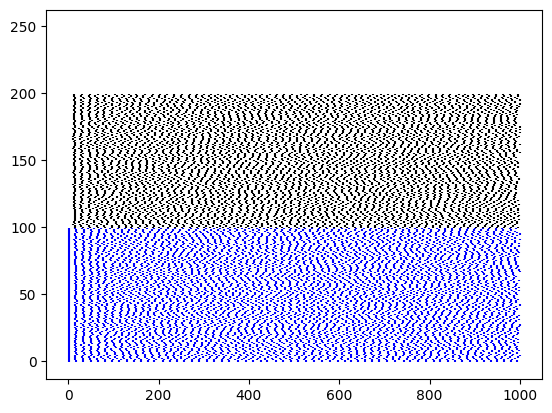

In [133]:
model2 = ConnectedClusters(
    N1=100, N2=100, Next=100,
    g=5, J=100, Ce=10, D=2e-3, vthr_ratio=2,
    
    I1=10000, I1_start=0, I1_end=0,
    I2=0, I2_start=0, I2_end=0)

model2.compute_activity(T = 1, dt = 1e-3)
#T and dt
model2.plot_raster()